## (This was created by claude code)


# Track quality diagnostics for the hourly StitchNodes run

**Motivation.** Plotting a single ETC track from `data/nodes_with_reports_final.csv`
showed a storm that crossed nearly the whole Northern Hemisphere and lived ~25 days.
That is not a cyclone. This notebook asks: *how many tracks are like that, and why?*

**Roadmap**

1. Audit my DetectNodes/StitchNodes parameters against Kiefer et al. (2026).
2. Parse the raw StitchNodes output and look at track duration / zonal extent.
3. Look at the per-timestep displacement — the diagnostic that identifies the cause.
4. Confirm the large displacements are real relocations, not detection jitter.
5. **Quantify** how many tracks are affected, in the raw file and in the DJFM/CONUS
   subset that actually feeds the analysis.
6. Audit input-data completeness.
7. Show what the record looks like if tracks are split at the bad linkages.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.insert(0, str(Path.cwd()))
from TE_processing import filter_tracks, LON_MIN, LON_MAX, LAT_MIN, LAT_MAX

NODEFILE = "/data1/lepique/TempestExtremes/tracks/tracks_hourly_1995_2025.txt"
CANDDIR  = Path("/data1/lepique/TempestExtremes/candidates")
REPORTS_CSV = "data/nodes_with_reports_final.csv"

pd.set_option("display.width", 140)

In [2]:
## Plot styling -------------------------------------------------------------
## Colors are slots 1-3 of the validated categorical palette (blue / orange /
## aqua). Those three are documented as clearing colorblind-safety and
## normal-vision separation floors for all pairs, so they are safe to use
## together in scatter/map form where every pair can appear side by side.
C_MAIN  = "#2a78d6"   # physically plausible / baseline
C_FLAG  = "#eb6834"   # flagged as spurious
C_ALT   = "#1baf7a"   # third series
INK     = "#0b0b0b"   # primary text
INK2    = "#52514e"   # secondary text
GRID    = "#d8d7d3"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "font.size": 9,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK2,
    "axes.titlecolor": INK,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.5,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})

def tidy(ax, xlabel=None, ylabel=None, title=None):
    """Strip chartjunk: no top/right spines, recessive grid, left-aligned title."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title, pad=10)
    return ax

## 1. Parameter audit: my run vs. Kiefer et al. (2026)

Sources:

- Theirs: [Kiefer_etal_2026/kiefer_etc_tracking_hourly.sh](Kiefer_etal_2026/kiefer_etc_tracking_hourly.sh),
  the `Sensitivity 2 -- HOURLY` block (lines 137-165).
- Mine: `/data1/lepique/TempestExtremes/run_tempest_hourly.sh`.

Values below are transcribed from those two scripts.

In [3]:
params = pd.DataFrame([
    # stage,        parameter,             Kiefer hourly,   mine,           note
    ("DetectNodes", "--searchbymin",       "MSL",           "msl",          "same field, ERA5 name"),
    ("DetectNodes", "closedcontour mag",   "200.0",         "200.0",        ""),
    ("DetectNodes", "closedcontour dist",  "6.0",           "6.0",          ""),
    ("DetectNodes", "--mergedist",         "9.01",          "9.01",         ""),
    ("DetectNodes", "--timestride",        "1",             "1 (default)",  "hourly either way"),
    ("DetectNodes", "--outputcmd 2nd var", "PHIS,max,0",    "z,max,0",      "surface geopotential; unused downstream"),
    ("StitchNodes", "--range",             "9.01",          "9.01",         "*** see below ***"),
    ("StitchNodes", "--minlength",         "24",            "24",           ""),
    ("StitchNodes", "--mintime",           "24h",           "24h",          ""),
    ("StitchNodes", "--maxgap",            "6",             "6",            ""),
    ("StitchNodes", "--min_endpoint_dist", "12.0",          "12.0",         ""),
    ("StitchNodes", "--threshold",         "lat/lon CONUS box", "lat/lon CONUS box", "identical string"),
], columns=["stage", "parameter", "kiefer", "mine", "note"])

params["match"] = np.where(
    params.kiefer.str.replace(r"\s+", "", regex=True).str.lower()
    == params.mine.str.replace(r"\s+", "", regex=True).str.lower(),
    "yes", "see note")

print(params.to_string(index=False))

      stage           parameter            kiefer              mine                                    note    match
DetectNodes       --searchbymin               MSL               msl                   same field, ERA5 name      yes
DetectNodes   closedcontour mag             200.0             200.0                                              yes
DetectNodes  closedcontour dist               6.0               6.0                                              yes
DetectNodes         --mergedist              9.01              9.01                                              yes
DetectNodes        --timestride                 1       1 (default)                       hourly either way see note
DetectNodes --outputcmd 2nd var        PHIS,max,0           z,max,0 surface geopotential; unused downstream see note
StitchNodes             --range              9.01              9.01                       *** see below ***      yes
StitchNodes         --minlength                24               

### 1a. The parameters match — but `--range` was never rescaled for hourly data

I am reproducing their setup faithfully. The problem is inherited from the setup itself.

Compare their own 6-hourly block (lines 124-133) with their hourly block (lines 137-146):

| parameter | 6-hourly | hourly | scaled by |
|---|---|---|---|
| `--minlength` (steps) | 4 | 24 | **x6** |
| `--maxgap` (steps) | 1 | 6 | **x6** |
| `--mintime` | 24h | 24h | x1 (a duration, correctly unchanged) |
| `--min_endpoint_dist` | 12.0 | 12.0 | x1 (a total distance, correctly unchanged) |
| **`--range`** (deg **per step**) | **9.01** | **9.01** | **x1 — but it is per-step, so it should be /6** |

`--minlength` and `--maxgap` are counted in timesteps and were correctly multiplied
by 6. `--range` is *also* per-timestep — it caps how far a center may move between
consecutive candidate times — but it was carried over unchanged.

What that means physically:

- at 6-hourly: 9.01 deg / 6 h ~ **167 km/h** (~46 m/s) — a fast but plausible ETC.
- at hourly:   9.01 deg / 1 h ~ **1002 km/h** (~278 m/s) — physically impossible.

So on hourly data StitchNodes is permitted to connect a cyclone to *any* pressure
minimum within ~1000 km at the next hour. Sections 3-5 test whether it actually does.

## 2. Parse the raw StitchNodes output

In [4]:
EARTH_R_KM = 6371.0

def haversine_km(lon1, lat1, lon2, lat2):
    """Great-circle distance (km); vectorized."""
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * EARTH_R_KM * np.arcsin(np.sqrt(a))


def parse_nodefile(path):
    """
    Parse a StitchNodes nodefile into one row per node.

    Header line : start <n_steps> <YYYY> <MM> <DD> <hour>
    Node line   : <i> <j> <lon> <lat> <msl> <z> <YYYY> <MM> <DD> <hour>

    track_id is 1-indexed, matching the convention in TE_processing.parse_nodefile
    so ids line up with data/nodes_with_reports_final.csv.
    """
    rows, tid = [], 0
    with open(path) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue
            if parts[0] == "start":
                tid += 1
                continue
            rows.append((tid,
                         float(parts[2]), float(parts[3]),
                         float(parts[4]) / 100.0,   # Pa -> hPa
                         float(parts[5]),
                         int(parts[6]), int(parts[7]), int(parts[8]), int(parts[9])))

    df = pd.DataFrame(rows, columns=["track_id", "lon", "lat", "msl", "z",
                                     "year", "month", "day", "hour"])
    df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
    return df.sort_values(["track_id", "datetime"]).reset_index(drop=True)


nodes = parse_nodefile(NODEFILE)
print(f"{len(nodes):,} nodes across {nodes.track_id.nunique():,} tracks")
print(f"period: {nodes.datetime.min()} -> {nodes.datetime.max()}")
nodes.head()

849,713 nodes across 6,263 tracks
period: 1995-12-01 00:00:00 -> 2025-12-31 23:00:00


,track_id,lon,lat,msl,z,year,month,day,hour,datetime
0,1,216.5,58.50,983.2175,1.946871,1995,12,1,0,1995-12-01 00:00:00
1,1,216.5,58.50,983.3931,1.946871,1995,12,1,1,1995-12-01 01:00:00
2,1,216.5,58.00,983.2056,3.209567,1995,12,1,2,1995-12-01 02:00:00
3,1,216.5,57.75,983.0194,0.650716,1995,12,1,3,1995-12-01 03:00:00
4,1,216.5,57.75,982.8556,0.650716,1995,12,1,4,1995-12-01 04:00:00


In [5]:
## Per-step kinematics. Steps are within-track only (first node of each track is NaN).
prev = nodes.groupby("track_id").shift(1)

nodes["step_km"] = haversine_km(prev.lon, prev.lat, nodes.lon, nodes.lat)
nodes["dt_h"]    = (nodes.datetime - prev.datetime).dt.total_seconds() / 3600
nodes["speed_kmh"] = nodes.step_km / nodes.dt_h
## signed longitude increment, wrapped to (-180, 180] so dateline crossings
## contribute their true small increment rather than a spurious 360
nodes["dlon"] = ((nodes.lon - prev.lon + 180) % 360) - 180

print("gap between consecutive nodes (hours):")
print(nodes.dt_h.value_counts().sort_index().head(10).to_string())

gap between consecutive nodes (hours):
dt_h
1.0     823921
2.0       8407
3.0       3953
4.0       2651
5.0       1848
6.0       1497
7.0       1171
25.0         1
26.0         1


## 3. Track duration and zonal extent

First, reproduce the symptom.

In [6]:
g = nodes.groupby("track_id")

trk = pd.DataFrame({
    "n_nodes":   g.size(),
    "start":     g.datetime.min(),
    "end":       g.datetime.max(),
    "lat_min":   g.lat.min(),
    "lat_max":   g.lat.max(),
    "min_msl":   g.msl.min(),
    "max_step_km": g.step_km.max(),
})
trk["duration_h"] = (trk.end - trk.start).dt.total_seconds() / 3600
trk["duration_d"] = trk.duration_h / 24
## cumulative zonal travel: sum of wrapped per-step dlon. 360 deg = once around.
trk["cum_dlon"] = nodes.groupby("track_id").dlon.sum().abs()

print(trk.duration_d.describe().round(2).to_string())
print()
for d in (5, 10, 15, 20, 25):
    n_ = (trk.duration_d > d).sum()
    print(f"  tracks lasting > {d:2d} days: {n_:5d}  ({100 * n_ / len(trk):5.2f}%)")
print()
print(f"  tracks travelling > 180 deg of longitude: {(trk.cum_dlon > 180).sum()}")
print(f"  tracks travelling > 360 deg of longitude: {(trk.cum_dlon > 360).sum()}")

count    6263.00
mean        5.92
std         4.30
min         1.00
25%         2.75
50%         4.75
75%         7.83
max        39.79

  tracks lasting >  5 days:  2941  (46.96%)
  tracks lasting > 10 days:   944  (15.07%)
  tracks lasting > 15 days:   277  ( 4.42%)
  tracks lasting > 20 days:    75  ( 1.20%)
  tracks lasting > 25 days:    14  ( 0.22%)

  tracks travelling > 180 deg of longitude: 172
  tracks travelling > 360 deg of longitude: 10


For reference: the observed lifetime of an extratropical cyclone is typically
**3-7 days**, and 10 days is already exceptional. Here the median is ~4.8 days but
the upper tail runs to **40 days**, and dozens of tracks circumnavigate the hemisphere.

In [7]:
## An example: the kind of track that motivated this notebook.
EXAMPLE_TID = 2736

ex = nodes[nodes.track_id == EXAMPLE_TID]
print(f"track {EXAMPLE_TID}: {len(ex)} nodes, "
      f"{ex.datetime.min()} -> {ex.datetime.max()} "
      f"({(ex.datetime.max() - ex.datetime.min()).total_seconds() / 86400:.1f} days)")
print(f"  longitude range   : {ex.lon.min():.1f} -> {ex.lon.max():.1f}")
print(f"  cumulative |dlon| : {trk.loc[EXAMPLE_TID, 'cum_dlon']:.0f} deg")
print(f"  largest 1-h step  : {ex.step_km.max():.0f} km")

track 2736: 618 nodes, 2009-01-10 04:00:00 -> 2009-02-05 14:00:00 (26.4 days)
  longitude range   : 2.2 -> 358.5
  cumulative |dlon| : 259 deg
  largest 1-h step  : 999 km


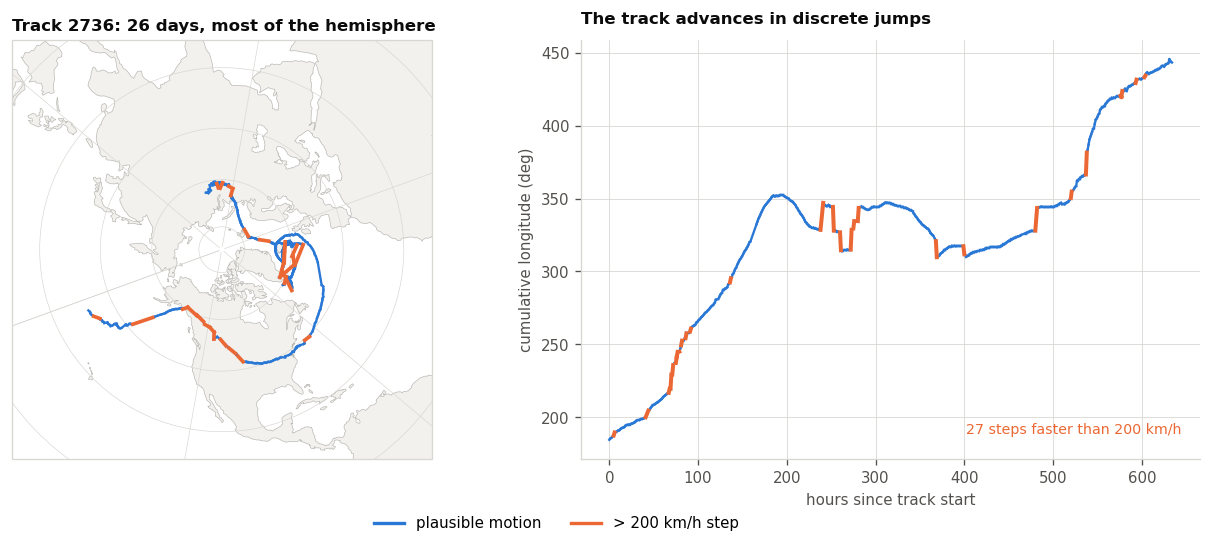

In [8]:
JUMP_KMH = 200.0   # threshold justified in section 4

fig = plt.figure(figsize=(11, 4.4))

## --- left: map ------------------------------------------------------------
ax = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo(central_longitude=250))
ax.set_extent([-180, 180, 12, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#f2f1ee")
ax.add_feature(cfeature.COASTLINE.with_scale("110m"), lw=0.4, edgecolor="#b8b7b2")
ax.gridlines(color=GRID, lw=0.4)

lon, lat = ex.lon.values, ex.lat.values
is_jump = (ex.speed_kmh.values > JUMP_KMH)
for k in range(1, len(ex)):
    ax.plot(lon[k - 1:k + 1], lat[k - 1:k + 1],
            color=C_FLAG if is_jump[k] else C_MAIN,
            lw=2.2 if is_jump[k] else 1.4,
            transform=ccrs.Geodetic(), zorder=3 if is_jump[k] else 2)
ax.set_title(f"Track {EXAMPLE_TID}: 26 days, most of the hemisphere")

## --- right: longitude vs time --------------------------------------------
ax2 = fig.add_subplot(1, 2, 2)
t_h = (ex.datetime - ex.datetime.min()).dt.total_seconds().values / 3600
lon_unwrap = ex.lon.iloc[0] + np.concatenate([[0], np.nancumsum(ex.dlon.values[1:])])
for k in range(1, len(ex)):
    ax2.plot(t_h[k - 1:k + 1], lon_unwrap[k - 1:k + 1],
             color=C_FLAG if is_jump[k] else C_MAIN,
             lw=2.4 if is_jump[k] else 1.4,
             zorder=3 if is_jump[k] else 2)
tidy(ax2, "hours since track start", "cumulative longitude (deg)",
     "The track advances in discrete jumps")
ax2.text(0.97, 0.06, f"{is_jump.sum()} steps faster than {JUMP_KMH:.0f} km/h",
         transform=ax2.transAxes, ha="right", color=C_FLAG, fontsize=8.5)

## one legend, since two colors encode two categories
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([], [], color=C_MAIN, lw=2, label="plausible motion"),
                    Line2D([], [], color=C_FLAG, lw=2, label=f"> {JUMP_KMH:.0f} km/h step")],
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout()
plt.show()

The right-hand panel is the tell. A real cyclone drifts eastward continuously. This
track sits nearly still for hours, then leaps ~1000 km, then sits still again. The
"25-day hemispheric cyclone" is a chain of *separate* storms welded together.

## 4. The per-timestep displacement distribution

If `--range` were sized correctly for hourly data, step displacements would follow a
single physical distribution. If it is 6x too permissive, we should instead see two
populations: real motion, plus a broad shelf of arbitrary linkages extending out to
the `--range` cap of 9.01 deg ~ 1002 km.

In [9]:
s = nodes.speed_kmh.dropna()
RANGE_KM = 9.01 * 2 * np.pi * EARTH_R_KM / 360   # --range converted to km

print(f"--range = 9.01 deg = {RANGE_KM:.0f} km per timestep")
print(f"largest observed 1-step displacement: {nodes.step_km.max():.0f} km")
print()
print("step speed (km/h) percentiles:")
for p in (50, 75, 90, 95, 99, 99.9):
    print(f"  p{p:<5}: {np.percentile(s, p):7.0f}")

--range = 9.01 deg = 1002 km per timestep
largest observed 1-step displacement: 1002 km

step speed (km/h) percentiles:
  p50   :      33
  p75   :      56
  p90   :     102
  p95   :     184
  p99   :     561
  p99.9 :     968


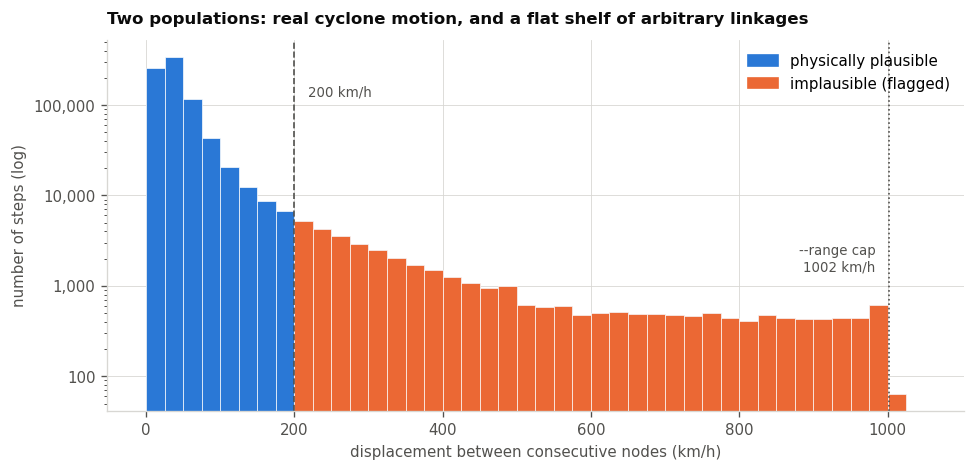

In [10]:
fig, ax = plt.subplots(figsize=(8.2, 4.0))

bins = np.arange(0, 1051, 25)
ax.hist(s, bins=bins, color=C_MAIN, edgecolor="white", linewidth=0.4)
## recolor the bars beyond the threshold: same histogram, flagged subset
ax.hist(s[s > JUMP_KMH], bins=bins, color=C_FLAG, edgecolor="white", linewidth=0.4)

ax.set_yscale("log")
ax.axvline(JUMP_KMH, color=INK2, lw=1, ls="--")
ax.axvline(RANGE_KM, color=INK2, lw=1, ls=":")
ax.annotate(f"--range cap\n{RANGE_KM:.0f} km/h", xy=(RANGE_KM, 2e3),
            xytext=(-8, 0), textcoords="offset points", ha="right",
            va="center", color=INK2, fontsize=8)
ax.annotate(f"{JUMP_KMH:.0f} km/h", xy=(JUMP_KMH, 1.4e5),
            xytext=(8, 0), textcoords="offset points",
            va="center", color=INK2, fontsize=8)
tidy(ax, "displacement between consecutive nodes (km/h)", "number of steps (log)",
     "Two populations: real cyclone motion, and a flat shelf of arbitrary linkages")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C_MAIN, label="physically plausible"),
                   Patch(color=C_FLAG, label="implausible (flagged)")],
          loc="upper right")
fig.tight_layout()
plt.show()

This is the diagnostic. The physical population peaks at **25-50 km/h** (~7-14 m/s,
exactly right for ETC translation) and has essentially decayed away by ~150-200 km/h.
Beyond that the histogram flattens into a **shelf that persists all the way to the
`--range` cap** and stops dead there. A physical process does not produce a flat
distribution that terminates precisely at a configuration parameter — that shelf is
StitchNodes reaching out to the edge of its allowed radius and grabbing whatever
minimum it finds.

`JUMP_KMH = 200` km/h (56 m/s) sits in the valley between the two populations. The
fastest documented ETC translation speeds are ~30-40 m/s, so this is a conservative
cut that will *under*-count the problem rather than over-count it.

In [11]:
for th in (150, 200, 250, 300):
    j = nodes.speed_kmh > th
    per_track = j.groupby(nodes.track_id).sum()
    print(f"speed > {th:3d} km/h ({th/3.6:4.0f} m/s): "
          f"{j.sum():6,} steps ({100*j.mean():5.2f}% of all steps) | "
          f"tracks with >=1 such step: {(per_track>0).sum():5,} "
          f"({100*(per_track>0).mean():5.1f}%)")

speed > 150 km/h (  42 m/s): 53,245 steps ( 6.27% of all steps) | tracks with >=1 such step: 6,070 ( 96.9%)
speed > 200 km/h (  56 m/s): 37,902 steps ( 4.46% of all steps) | tracks with >=1 such step: 5,864 ( 93.6%)
speed > 250 km/h (  69 m/s): 28,410 steps ( 3.34% of all steps) | tracks with >=1 such step: 5,582 ( 89.1%)
speed > 300 km/h (  83 m/s): 21,930 steps ( 2.58% of all steps) | tracks with >=1 such step: 5,226 ( 83.4%)


## 5. Are the jumps real relocations, or detection jitter?

A large displacement could be benign: a broad low with two competing minima can make
the detected center flicker back and forth without the storm going anywhere. That
would be noise, not a broken track.

Test: for each flagged step, compare the mean position over the **6 hours before**
with the mean position over the **6 hours after**. Jitter returns to where it came
from; a bad linkage moves and stays moved.

In [12]:
nodes["jump"] = nodes.speed_kmh > JUMP_KMH

def relocation_distances(df, win=6):
    """Distance between mean position `win` hours before vs after each flagged step."""
    out = []
    for _, gr in df.groupby("track_id"):
        gr = gr.reset_index(drop=True)
        for i in np.flatnonzero(gr.jump.values):
            if i - win < 0 or i + win > len(gr):
                continue
            before, after = gr.iloc[i - win:i], gr.iloc[i:i + win]
            out.append(haversine_km(before.lon.mean(), before.lat.mean(),
                                    after.lon.mean(),  after.lat.mean()))
    return np.asarray(out)

reloc = relocation_distances(nodes)
print(f"evaluated {len(reloc):,} flagged steps with a full +/-6 h window\n")
print(f"  median durable relocation : {np.median(reloc):6.0f} km")
print(f"  transient  (< 150 km)     : {100*(reloc < 150).mean():5.1f}%  <- jitter")
print(f"  durable    (> 400 km)     : {100*(reloc > 400).mean():5.1f}%  <- broken linkage")

evaluated 34,525 flagged steps with a full +/-6 h window

  median durable relocation :    499 km
  transient  (< 150 km)     :   4.7%  <- jitter
  durable    (> 400 km)     :  66.0%  <- broken linkage


Only ~5% of flagged steps are jitter. **Two thirds move the center more than 400 km
and leave it there** — the tracker has switched to a different storm and kept going.
These are genuine mis-linkages, not a plotting or detection artifact.

## 6. How many tracks are affected?

The headline numbers — for the raw file and for the DJFM/CONUS subset that actually
feeds the analysis (`filter_tracks` from `TE_processing.py`, the same call that built
`data/nodes_with_reports_final.csv`).

In [13]:
trk["n_jumps"] = nodes.groupby("track_id").jump.sum()

## the analysis subset: same filter used to build nodes_with_reports_final.csv
analysis = filter_tracks(nodes, seasons=(1996, 2025))
analysis_ids = analysis.track_id.unique()

## confirm the ids really do line up with the saved CSV
reports = pd.read_csv(REPORTS_CSV, parse_dates=["time_hour"])
print(f"filter_tracks -> {len(analysis_ids):,} tracks / {len(analysis):,} nodes")
print(f"saved CSV     -> {reports.track_id.nunique():,} tracks / {len(reports):,} rows")
print(f"track_id sets identical: {set(analysis_ids) == set(reports.track_id.unique())}\n")

for label, sub in [("ALL tracks in nodefile", trk),
                   ("DJFM + CONUS analysis subset", trk.loc[analysis_ids])]:
    n = len(sub)
    print(f"--- {label} (n = {n:,}) ---")
    for k in (1, 3, 5, 10):
        c = (sub.n_jumps >= k).sum()
        print(f"    >= {k:2d} implausible step(s): {c:5,}  ({100*c/n:5.1f}%)")
    print(f"    median jumps per track   : {sub.n_jumps.median():.0f}")
    print(f"    median duration          : {sub.duration_d.median():.1f} d")
    print()

filter_tracks -> 2,225 tracks / 264,406 nodes
saved CSV     -> 2,225 tracks / 264,406 rows
track_id sets identical: True

--- ALL tracks in nodefile (n = 6,263) ---
    >=  1 implausible step(s): 5,864  ( 93.6%)
    >=  3 implausible step(s): 4,576  ( 73.1%)
    >=  5 implausible step(s): 3,271  ( 52.2%)
    >= 10 implausible step(s): 1,274  ( 20.3%)
    median jumps per track   : 5
    median duration          : 4.8 d

--- DJFM + CONUS analysis subset (n = 2,225) ---
    >=  1 implausible step(s): 2,128  ( 95.6%)
    >=  3 implausible step(s): 1,714  ( 77.0%)
    >=  5 implausible step(s): 1,268  ( 57.0%)
    >= 10 implausible step(s):   507  ( 22.8%)
    median jumps per track   : 5
    median duration          : 4.4 d



In [14]:
## Contamination grows with track length -- exactly what chaining predicts.
bins  = [0, 2, 5, 10, 15, 20, 100]
labels = ["0-2 d", "2-5 d", "5-10 d", "10-15 d", "15-20 d", "> 20 d"]
trk["dur_bin"] = pd.cut(trk.duration_d, bins, labels=labels)

by_dur = trk.groupby("dur_bin", observed=True).agg(
    n_tracks=("n_jumps", "size"),
    frac_with_jump=("n_jumps", lambda x: (x > 0).mean()),
    median_jumps=("n_jumps", "median"),
    mean_cum_dlon=("cum_dlon", "mean"),
).round(2)
print(by_dur.to_string())

         n_tracks  frac_with_jump  median_jumps  mean_cum_dlon
dur_bin                                                       
0-2 d         860            0.85           2.0          20.19
2-5 d        2462            0.93           4.0          34.05
5-10 d       1997            0.97           6.0          62.88
10-15 d       667            0.97          10.0         107.54
15-20 d       202            0.97          12.0         139.02
> 20 d         75            0.99          15.0         155.77


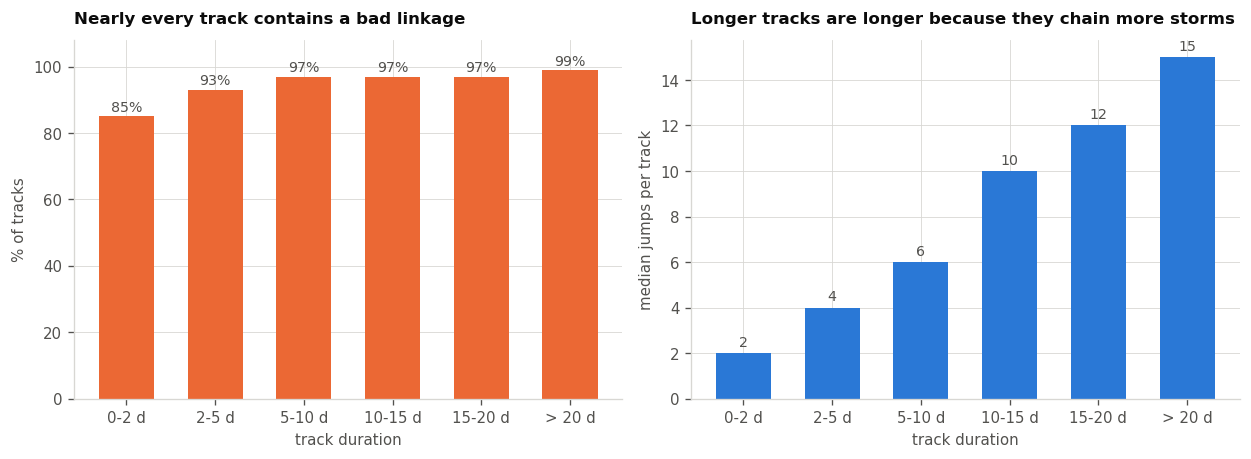

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))

## --- left: share of tracks containing >=1 bad linkage ---------------------
ax = axes[0]
y = by_dur.frac_with_jump * 100
ax.bar(range(len(y)), y, color=C_FLAG, width=0.62)
for i, v in enumerate(y):                      # direct labels, neutral ink
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=8.5, color=INK2)
ax.set_xticks(range(len(y)))
ax.set_xticklabels(by_dur.index, rotation=0)
ax.set_ylim(0, 108)
tidy(ax, "track duration", "% of tracks", "Nearly every track contains a bad linkage")

## --- right: how many bad linkages ----------------------------------------
ax = axes[1]
ax.bar(range(len(by_dur)), by_dur.median_jumps, color=C_MAIN, width=0.62)
for i, v in enumerate(by_dur.median_jumps):
    ax.text(i, v + 0.3, f"{v:.0f}", ha="center", fontsize=8.5, color=INK2)
ax.set_xticks(range(len(by_dur)))
ax.set_xticklabels(by_dur.index)
tidy(ax, "track duration", "median jumps per track",
     "Longer tracks are longer because they chain more storms")

fig.tight_layout()
plt.show()

The result is not "a handful of pathological tracks." **Contamination is the norm.**
Even 0-2 day tracks are ~85% affected; past 10 days it is ~97%. Track duration in this
dataset is largely a measure of *how many separate cyclones got welded together*, not
of how long any storm lived.

## 7. Input-data completeness

Separate check, unrelated to `--range`: are there hours missing from the candidate
files? A missing hour lets StitchNodes bridge a gap larger than `--maxgap` allows,
because the gap is counted in *available candidate timesteps*, not wall-clock hours.

In [16]:
import calendar, re

recs = []
for f in sorted(CANDDIR.glob("candidates_hourly_[0-9]*_[0-9]*.txt")):
    m = re.search(r"_(\d{4})_(\d{2})\.txt$", f.name)
    if not m:
        continue
    year, month = int(m.group(1)), int(m.group(2))
    ## header lines are the un-indented ones: YYYY MM DD <count> HH
    times = set()
    with open(f) as fh:
        for ln in fh:
            if ln and not ln.startswith("\t"):
                p = ln.split()
                if len(p) == 5:
                    times.add((int(p[0]), int(p[1]), int(p[2]), int(p[4])))
    expected = calendar.monthrange(year, month)[1] * 24
    recs.append({"year": year, "month": month,
                 "n_hours": len(times), "expected": expected,
                 "missing": expected - len(times)})

cand = pd.DataFrame(recs)
print(f"{len(cand)} monthly candidate files, {cand.year.min()}-{cand.year.max()}")
print(f"total missing hours: {cand.missing.sum()}\n")
print(cand[cand.missing != 0].to_string(index=False))

361 monthly candidate files, 1995-2025
total missing hours: 24

 year  month  n_hours  expected  missing
 1995     12      720       744       24


In [17]:
## Consequence: steps that span more wall-clock time than --maxgap 6 permits.
odd = nodes[nodes.dt_h > 7]
print(f"{len(odd)} step(s) span more than 7 h despite --maxgap 6:\n")
print(odd[["track_id", "datetime", "dt_h", "lon", "lat"]].to_string(index=False))

2 step(s) span more than 7 h despite --maxgap 6:

 track_id   datetime  dt_h    lon   lat
       18 1996-01-01  25.0 206.75 47.50
       19 1996-01-01  26.0 259.50 33.75


Minor, and separable from the main issue: **December 1995 has only 720 of 744 hours**
(one day short), which lets two tracks bridge a ~25 h gap. Worth re-running that month,
but it affects 2 tracks — it is not the cause of the runaway tracks.

## 8. What the record looks like if the bad linkages are cut

I am not changing the tracking parameters. But splitting the existing tracks at every
flagged step — and then re-imposing StitchNodes' own survival criteria on the pieces
(`--minlength 24`, `--mintime 24h`, `--min_endpoint_dist 12.0`) — gives a rough sense
of what the run would have produced with a correctly scaled `--range`.

This is an *approximation*, not a substitute for re-stitching: a correct `--range`
would also have let StitchNodes pick a **different**, closer successor at each step
rather than simply dropping the linkage. Treat the numbers as indicative.

In [18]:
MIN_LENGTH   = 24     # nodes
MIN_TIME_H   = 24     # hours
MIN_ENDPT_KM = 12.0 * 2 * np.pi * EARTH_R_KM / 360   # 12 deg -> km

## a new segment starts at each flagged step
seg = nodes.jump.fillna(False).groupby(nodes.track_id).cumsum()
nodes["segment_id"] = nodes.track_id.astype(str) + "_" + seg.astype(int).astype(str)

sg = nodes.groupby("segment_id")
segs = pd.DataFrame({
    "n_nodes":  sg.size(),
    "duration_h": (sg.datetime.max() - sg.datetime.min()).dt.total_seconds() / 3600,
    "endpoint_km": haversine_km(sg.lon.first(), sg.lat.first(),
                                sg.lon.last(),  sg.lat.last()),
})
kept = segs[(segs.n_nodes >= MIN_LENGTH)
            & (segs.duration_h >= MIN_TIME_H)
            & (segs.endpoint_km >= MIN_ENDPT_KM)]

print(f"original tracks                : {len(trk):6,}   median {trk.duration_d.median():5.1f} d, "
      f"max {trk.duration_d.max():5.1f} d")
print(f"segments after cutting linkages: {len(segs):6,}")
print(f"segments surviving SN criteria : {len(kept):6,}   median {kept.duration_h.median()/24:5.1f} d, "
      f"max {kept.duration_h.max()/24:5.1f} d")
print()
print(f"nodes retained: {kept.n_nodes.sum():,} / {len(nodes):,} "
      f"({100*kept.n_nodes.sum()/len(nodes):.0f}%)")
print()
print(f"tracks longer than 10 days: {(trk.duration_d > 10).sum():,} "
      f"({100*(trk.duration_d > 10).mean():.1f}%)  ->  "
      f"{(kept.duration_h/24 > 10).sum():,} ({100*(kept.duration_h/24 > 10).mean():.1f}%)")

original tracks                :  6,263   median   4.8 d, max  39.8 d
segments after cutting linkages: 44,165
segments surviving SN criteria :  4,982   median   2.4 d, max  23.3 d

nodes retained: 346,882 / 849,713 (41%)

tracks longer than 10 days: 944 (15.1%)  ->  97 (1.9%)


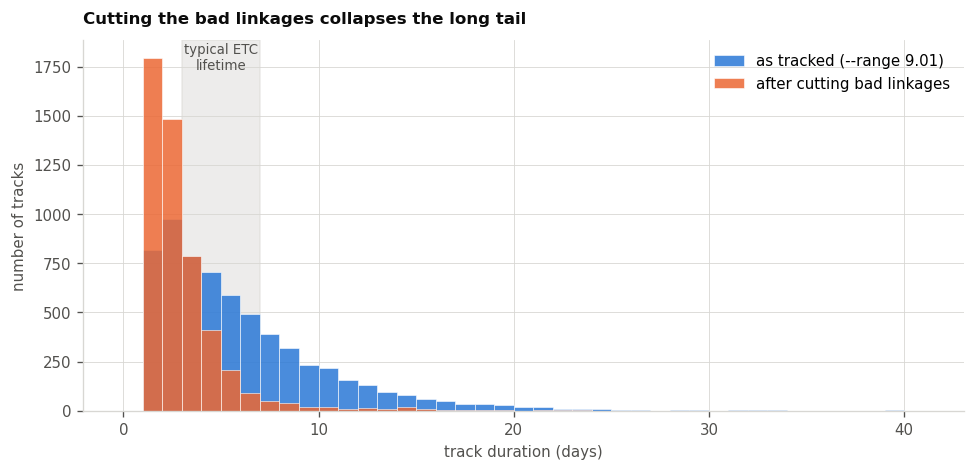

In [19]:
fig, ax = plt.subplots(figsize=(8.2, 4.0))

bins = np.arange(0, 42, 1)
ax.hist(trk.duration_d, bins=bins, color=C_MAIN, alpha=0.85,
        edgecolor="white", linewidth=0.4, label="as tracked (--range 9.01)")
ax.hist(kept.duration_h / 24, bins=bins, color=C_FLAG, alpha=0.85,
        edgecolor="white", linewidth=0.4, label="after cutting bad linkages")

ax.axvspan(3, 7, color=GRID, alpha=0.45, zorder=0)
ax.text(5, ax.get_ylim()[1] * 0.92, "typical ETC\nlifetime", ha="center",
        fontsize=8, color=INK2)
tidy(ax, "track duration (days)", "number of tracks",
     "Cutting the bad linkages collapses the long tail")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

The >10-day population falls from **15.1% to 1.9%** of tracks and the median lifetime
drops from 4.8 to 2.4 days. Note the median now sits slightly *below* the physical
3-7 day range and only 41% of nodes survive — splitting truncates storms that a proper
re-stitch would have followed correctly, so this over-corrects. Again: indicative of
the scale of the problem, not a repaired dataset.

## Summary

**What is wrong.** `--range 9.01` degrees is a *per-timestep* cap on cyclone motion.
It was tuned for 6-hourly data (~167 km/h — plausible). The Kiefer hourly
configuration scaled `--minlength` and `--maxgap` by 6 for the switch to hourly data
but left `--range` unchanged, so on hourly data it permits **~1000 km/h**. StitchNodes
therefore links each cyclone to whatever pressure minimum lies within ~1000 km at the
next hour.

**Evidence.**

- Step-displacement histogram is bimodal: a physical mode at 25-50 km/h, plus a flat
  shelf running out to exactly the `--range` cap and stopping there (section 4).
- Only 4.7% of flagged steps are jitter; 66% relocate the center >400 km and leave it
  there (median 499 km). These are real mis-linkages, not detection noise (section 5).

**How many tracks are affected.**

| | tracks | >=1 bad linkage | >=5 bad linkages |
|---|---|---|---|
| full nodefile | 6,263 | 93.6% | 52.2% |
| DJFM + CONUS analysis subset | 2,225 | 95.6% | 57.0% |

Contamination scales with duration (85% of 0-2 day tracks -> 99% of >20 day tracks),
because chaining is *what makes* tracks long. Median tracked lifetime is 4.8 days
against a physical expectation of 3-7, so the *typical* track is not badly distorted
even where it contains a linkage or two; the long tail is essentially all artifact.

**My parameters do faithfully match Kiefer et al. (2026)** (section 1) — this is
inherited from their hourly configuration, not a transcription error on my part.

**Options.**

1. Re-run StitchNodes with `--range ~1.5` (= 9.01/6, preserving their intended
   physical speed limit). DetectNodes output is unchanged, so only the cheap stitching
   step reruns.
2. Keep the run as-is and split tracks post-hoc at implausible steps (section 8).
3. Ask the Kiefer authors whether `--range 9.01` at hourly resolution was deliberate.

Also worth fixing independently: December 1995 is missing 24 hours of candidates
(section 7).